# Proyecto ML - Clasificación de Comentarios Acusatorios

**Curso:** Machine Learning - Semestre 8

**Autor:** James Soto

**Dataset:** Kapak (contratación pública)

In [3]:
# Instalación de dependencias y descarga del dataset
!pip install -q scikit-learn pandas matplotlib seaborn scipy openpyxl

import os
if not os.path.exists('dataset.xlsx'):
    !wget -q https://github.com/rosvjames/machineLearningProyecto/blob/master/dataset.xlsx

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar dataset
df = pd.read_excel('dataset.xlsx', engine="openpyxl")

print(f"Shape del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}\n")
print(df.dtypes)
print("\n--- Primeras 5 filas ---")
df.head()

Shape del dataset: (5005, 5)
Columnas: ['contract_id', 'pregunta_id', 'pregunta', 'sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']

contract_id                     int64
pregunta_id                     int64
pregunta                       object
sum_pregunta_isAcusatoria       int64
final_pregunta_isAcusatoria     int64
dtype: object

--- Primeras 5 filas ---


,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0
3,682361,18263,Se puede ofertar un equipo que utilice cubetas...,0,0
4,1224444,18782,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0,0


## 1. Exploratory Data Analysis (EDA)




Distribución de clases:
  Clase 0 (No acusatoria): 4858 (97.06%)
  Clase 1 (Acusatoria):    147 (2.94%)
  Ratio desbalance:        33.0:1


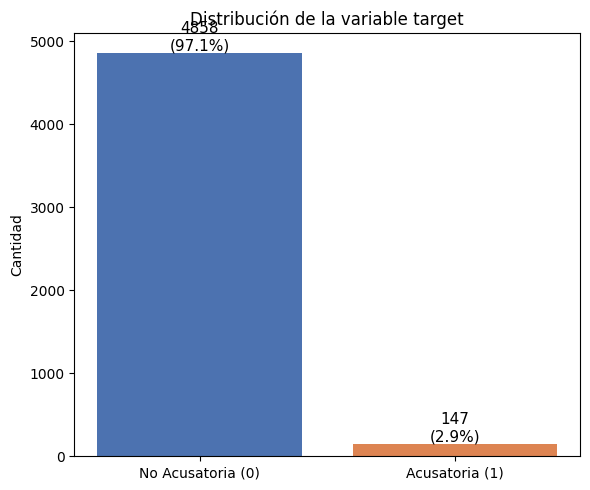

In [5]:
# --- 1.1 Distribución de clases ---
# Verificamos qué tan balanceada está la variable target.
# En clasificación binaria, un desbalance severo afecta el rendimiento
# de los modelos si no se maneja adecuadamente.

counts = df['final_pregunta_isAcusatoria'].value_counts()
percentages = df['final_pregunta_isAcusatoria'].value_counts(normalize=True) * 100

print("Distribución de clases:")
print(f"  Clase 0 (No acusatoria): {counts[0]} ({percentages[0]:.2f}%)")
print(f"  Clase 1 (Acusatoria):    {counts[1]} ({percentages[1]:.2f}%)")
print(f"  Ratio desbalance:        {counts[0]/counts[1]:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No Acusatoria (0)', 'Acusatoria (1)'], counts.values,
              color=['#4C72B0', '#DD8452'])
for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Cantidad')
ax.set_title('Distribución de la variable target')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7046/163384105.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='final_pregunta_isAcusatoria', y='longitud_texto', data=df, ax=axes[1],
/tmp/ipykernel_7046/163384105.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Acusatoria (0)', 'Acusatoria (1)'])


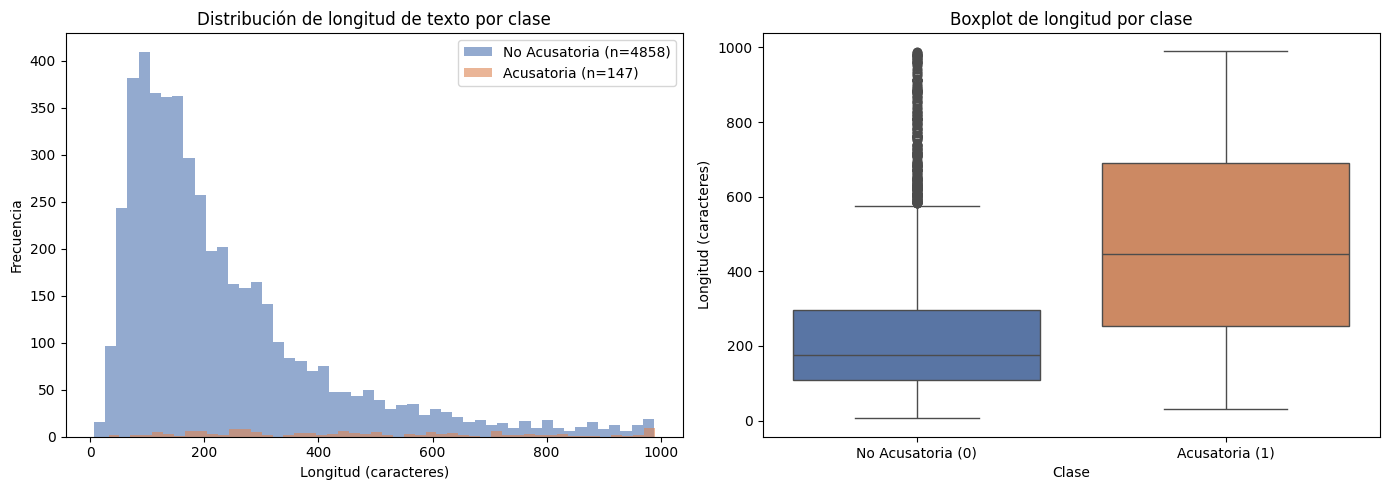

Estadísticas de longitud por clase:
                              count   mean    std   min    25%    50%    75%  \
final_pregunta_isAcusatoria                                                    
0                            4858.0  234.2  182.4   6.0  108.0  176.0  296.0   
1                             147.0  477.4  266.4  32.0  253.0  446.0  690.0   

                               max  
final_pregunta_isAcusatoria         
0                            988.0  
1                            990.0  


In [6]:
# --- 1.2 Distribución de longitudes de texto por clase ---
# Analizamos si las preguntas acusatorias tienden a ser más largas o cortas
# que las no acusatorias. Diferencias en longitud pueden ser un feature útil.

df['longitud_texto'] = df['pregunta'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma superpuesto
for label, color, name in [(0, '#4C72B0', 'No Acusatoria'), (1, '#DD8452', 'Acusatoria')]:
    subset = df[df['final_pregunta_isAcusatoria'] == label]['longitud_texto']
    axes[0].hist(subset, bins=50, alpha=0.6, label=f'{name} (n={len(subset)})', color=color)
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de texto por clase')
axes[0].legend()

# Boxplot comparativo
sns.boxplot(x='final_pregunta_isAcusatoria', y='longitud_texto', data=df, ax=axes[1],
            palette=['#4C72B0', '#DD8452'])
axes[1].set_xticklabels(['No Acusatoria (0)', 'Acusatoria (1)'])
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Longitud (caracteres)')
axes[1].set_title('Boxplot de longitud por clase')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por clase
print("Estadísticas de longitud por clase:")
print(df.groupby('final_pregunta_isAcusatoria')['longitud_texto'].describe().round(1))

Valores únicos de sum_pregunta_isAcusatoria: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Distribución de votos:
sum_pregunta_isAcusatoria
0    4640
1     218
2      77
3      70
Name: count, dtype: int64


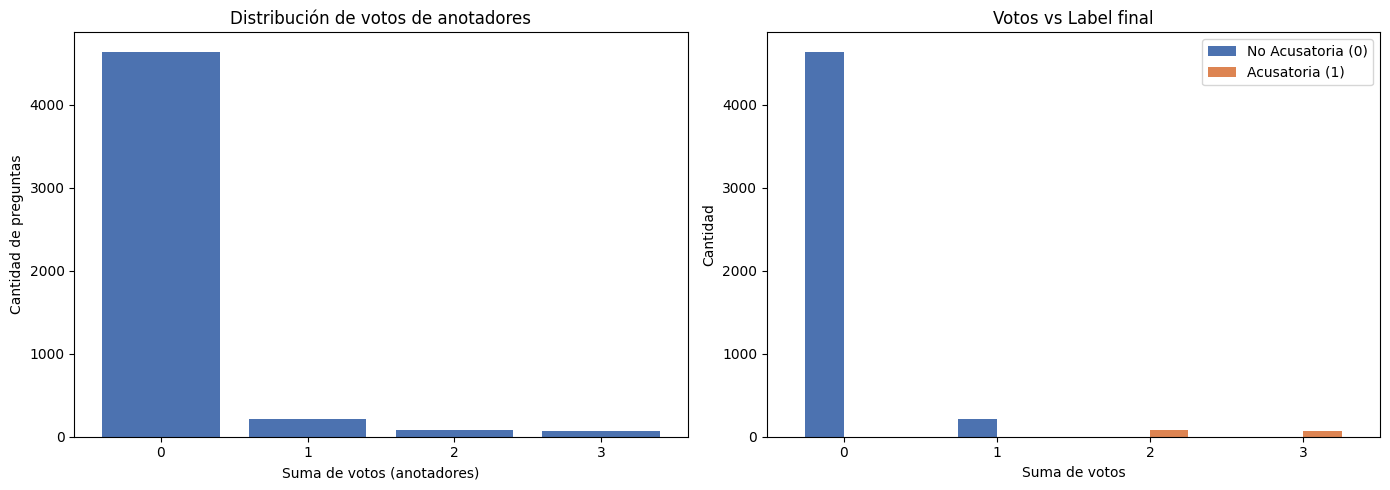


Tabla cruzada: sum_votos vs label final
final_pregunta_isAcusatoria     0    1  Total
sum_pregunta_isAcusatoria                    
0                            4640    0   4640
1                             218    0    218
2                               0   77     77
3                               0   70     70
Total                        4858  147   5005


In [7]:
# --- 1.3 Análisis de la columna 'sum_pregunta_isAcusatoria' ---
# Esta columna refleja la suma de votos de los anotadores humanos.
# Nos permite entender el proceso de etiquetado: cuántos anotadores
# coincidieron en clasificar cada pregunta como acusatoria.
# Un valor alto indica consenso fuerte; valores intermedios indican desacuerdo.

print("Valores únicos de sum_pregunta_isAcusatoria:", sorted(df['sum_pregunta_isAcusatoria'].unique()))
print("\nDistribución de votos:")
print(df['sum_pregunta_isAcusatoria'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución general de votos
vote_counts = df['sum_pregunta_isAcusatoria'].value_counts().sort_index()
axes[0].bar(vote_counts.index, vote_counts.values, color='#4C72B0')
axes[0].set_xlabel('Suma de votos (anotadores)')
axes[0].set_ylabel('Cantidad de preguntas')
axes[0].set_title('Distribución de votos de anotadores')
axes[0].set_xticks(vote_counts.index)

# Relación entre suma de votos y label final
cross = df.groupby(['sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_xlabel('Suma de votos')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Votos vs Label final')
axes[1].legend(['No Acusatoria (0)', 'Acusatoria (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Mostrar la tabla cruzada
print("\nTabla cruzada: sum_votos vs label final")
print(pd.crosstab(df['sum_pregunta_isAcusatoria'], df['final_pregunta_isAcusatoria'],
                  margins=True, margins_name='Total'))

In [8]:
# --- 1.4 Verificación de duplicados ---
# Verificamos si hay preguntas duplicadas en el texto.
# Los duplicados pueden inflar artificialmente las métricas si caen
# en train y test simultáneamente, por lo que es importante detectarlos.

duplicados_texto = df['pregunta'].duplicated().sum()
duplicados_total = df.duplicated().sum()

print(f"Duplicados en columna 'pregunta': {duplicados_texto}")
print(f"Filas completamente duplicadas:   {duplicados_total}")
print(f"Filas únicas por texto:           {df['pregunta'].nunique()} de {len(df)}")

if duplicados_texto > 0:
    print(f"\n--- Ejemplos de preguntas duplicadas ---")
    dup_mask = df['pregunta'].duplicated(keep=False)
    dup_examples = df[dup_mask].sort_values('pregunta').head(10)
    for _, row in dup_examples.iterrows():
        print(f"  [label={row['final_pregunta_isAcusatoria']}] {row['pregunta'][:100]}...")

# Verificar si hay duplicados con labels contradictorios
dup_preguntas = df.groupby('pregunta')['final_pregunta_isAcusatoria'].nunique()
contradictorios = (dup_preguntas > 1).sum()
print(f"\nPreguntas duplicadas con labels contradictorios: {contradictorios}")

Duplicados en columna 'pregunta': 147
Filas completamente duplicadas:   2
Filas únicas por texto:           4858 de 5005

--- Ejemplos de preguntas duplicadas ---
  [label=0] 1 ) Es necesario entregar las herramientas? 2)Cuántas personas se necesitan pararealizar laslabores ...
  [label=0] 1 ) Es necesario entregar las herramientas? 2)Cuántas personas se necesitan pararealizar laslabores ...
  [label=0] 1 ) ¿Es necesario entregar papel higiénico, jabón de tocador y dispensadores para estos, deser el ca...
  [label=0] 1 ) ¿Es necesario entregar papel higiénico, jabón de tocador y dispensadores para estos, deser el ca...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGAT

## 2. Feature Extraction

In [9]:
# =========================
# Imports necesarios
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

from scipy import stats

# Transfer learning
from sentence_transformers import SentenceTransformer

# Variables
X = df['pregunta']
y = df['final_pregunta_isAcusatoria']  # o 'target' si lo renombraron

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


#### Modelo 1: TF-IDF

In [10]:
tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95
    )),
    ('clf', LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ))
])

tfidf_pipeline.fit(X_train, y_train)
y_pred_tfidf = tfidf_pipeline.predict(X_test)

print("===== TF-IDF =====")
print("F1:", f1_score(y_test, y_pred_tfidf))
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))

===== TF-IDF =====
F1: 0.4594594594594595
Accuracy: 0.9600399600399601


#### Modelo 2: Transfer Learning

In [11]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Convertir texto a embeddings
X_train_emb = model.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model.encode(X_test.tolist(), show_progress_bar=True)

clf_emb = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

clf_emb.fit(X_train_emb, y_train)
y_pred_emb = clf_emb.predict(X_test_emb)

print("===== TRANSFER LEARNING =====")
print("F1:", f1_score(y_test, y_pred_emb))
print("Accuracy:", accuracy_score(y_test, y_pred_emb))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/126 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

===== TRANSFER LEARNING =====
F1: 0.3
Accuracy: 0.9020979020979021


#### Validación Cruzada

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# TF-IDF
scores_tfidf = cross_val_score(
    tfidf_pipeline,
    X, y,
    cv=skf,
    scoring='f1'
)

# Transfer Learning (manual porque hay embeddings)
scores_emb = []

for train_idx, val_idx in skf.split(X, y):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    X_tr_emb = model.encode(X_tr.tolist(), show_progress_bar=False)
    X_val_emb = model.encode(X_val.tolist(), show_progress_bar=False)

    clf = LogisticRegression(max_iter=3000, class_weight='balanced')
    clf.fit(X_tr_emb, y_tr)

    y_val_pred = clf.predict(X_val_emb)
    scores_emb.append(f1_score(y_val, y_val_pred))

scores_emb = np.array(scores_emb)

print("F1 por fold:")
print("TF-IDF:", scores_tfidf)
print("Embeddings:", scores_emb)

print("\nPromedios:")
print("TF-IDF:", scores_tfidf.mean())
print("Embeddings:", scores_emb.mean())

F1 por fold:
TF-IDF: [0.4109589  0.47887324 0.5        0.52054795 0.50632911]
Embeddings: [0.31343284 0.30882353 0.33333333 0.26993865 0.35714286]

Promedios:
TF-IDF: 0.4833418405351478
Embeddings: 0.31653424120311985


#### Test Estadístico

In [13]:
# H0: ambos modelos tienen el mismo rendimiento
# H1: hay diferencia significativa

t_stat, p_value = stats.ttest_rel(scores_tfidf, scores_emb)

print("===== TEST DE HIPÓTESIS =====")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Se rechaza H0 → Sí hay diferencia significativa entre los modelos")
else:
    print("No se rechaza H0 → No hay diferencia significativa")

===== TEST DE HIPÓTESIS =====
t-statistic: 6.769480760997254
p-value: 0.0024845641084620586
Se rechaza H0 → Sí hay diferencia significativa entre los modelos


## 3. Feature Selection

In [14]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

## Pipeline con feature selection

# Número de features a conservar
k = 2000

tfidf_fs_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95
    )),
    ('select', SelectKBest(score_func=chi2, k=k)),
    ('clf', LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ))
])

tfidf_fs_pipeline.fit(X_train, y_train)
y_pred_fs = tfidf_fs_pipeline.predict(X_test)

print("===== TF-IDF + Feature Selection =====")
print("F1:", f1_score(y_test, y_pred_fs))
print("Accuracy:", accuracy_score(y_test, y_pred_fs))
print(classification_report(y_test, y_pred_fs))

## Ver los features seleccinados más importantes

vectorizer = tfidf_fs_pipeline.named_steps['tfidf']
selector = tfidf_fs_pipeline.named_steps['select']

feature_names = np.array(vectorizer.get_feature_names_out())
selected_mask = selector.get_support()

selected_features = feature_names[selected_mask]
selected_scores = selector.scores_[selected_mask]

top_idx = np.argsort(selected_scores)[::-1][:30]

top_features_df = pd.DataFrame({
    'feature': selected_features[top_idx],
    'chi2_score': selected_scores[top_idx]
})

print("Top 30 features seleccionadas:")
display(top_features_df)

===== TF-IDF + Feature Selection =====
F1: 0.4578313253012048
Accuracy: 0.955044955044955
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       972
           1       0.35      0.66      0.46        29

    accuracy                           0.96      1001
   macro avg       0.67      0.81      0.72      1001
weighted avg       0.97      0.96      0.96      1001

Top 30 features seleccionadas:


,feature,chi2_score
0,direccionado,27.770934
1,transparencia,23.637581
2,amarrado,22.667605
3,supone que,21.771372
4,se supone,21.771372
5,no pueden,20.282032
6,casa comercial,19.390528
7,direccionado para,19.183717
8,produccion nacional,18.905384
9,la produccion,18.749823


#### Comparación de TF-IDF normal vs TF-IDF con feature selection

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline base sin feature selection
tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95
    )),
    ('clf', LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ))
])

scores_tfidf = cross_val_score(
    tfidf_pipeline,
    X, y,
    cv=skf,
    scoring='f1'
)

scores_tfidf_fs = cross_val_score(
    tfidf_fs_pipeline,
    X, y,
    cv=skf,
    scoring='f1'
)

print("F1 por fold:")
print("TF-IDF:", scores_tfidf)
print("TF-IDF + Feature Selection:", scores_tfidf_fs)

print("\nPromedios:")
print("TF-IDF:", scores_tfidf.mean())
print("TF-IDF + Feature Selection:", scores_tfidf_fs.mean())

F1 por fold:
TF-IDF: [0.4109589  0.47887324 0.5        0.52054795 0.50632911]
TF-IDF + Feature Selection: [0.43181818 0.48648649 0.49350649 0.45783133 0.49438202]

Promedios:
TF-IDF: 0.4833418405351478
TF-IDF + Feature Selection: 0.4728049019168553


#### Test de hipótesis

In [16]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(scores_tfidf, scores_tfidf_fs)

print("===== TEST DE HIPÓTESIS =====")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Se rechaza H0: sí existe diferencia significativa entre TF-IDF y TF-IDF + Feature Selection.")
else:
    print("No se rechaza H0: no existe evidencia suficiente de diferencia significativa.")

===== TEST DE HIPÓTESIS =====
t-statistic: 0.7398936573032302
p-value: 0.5004371168318638
No se rechaza H0: no existe evidencia suficiente de diferencia significativa.
